In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import random
import numpy as np
import torch
import matplotlib.pyplot as plt

from collections import deque
from scipy.linalg import block_diag

import kind
import ex_duffing
import util_data
import util_dyna
import util_nn

In [2]:
# --! define a reward function --!

class quadratic_fun:
    def __init__(self, matrix):
        self.matrix = np.atleast_2d(matrix)

    def __call__(self, x):
        return np.dot(x, np.dot(self.matrix, x.T))

state_ndim = 2
action_ndim = 1

state_cost = 1.0 * np.eye(state_ndim)
action_cost = 1.0 * np.eye(action_ndim)

reward_fn = quadratic_fun(block_diag(-state_cost, -action_cost))

In [3]:
# --! make a real simulation environment for a Duffing oscillator --!

duffing = util_dyna.torch_environment(ex_duffing.make_duffing('id', reward_fn))

In [4]:
# --! make a base policy --!

class policy_base:

    def __init__(self, gain):
        self.gain = torch.from_numpy(gain).to(torch.float32)

    def __call__(self, obs):
        return -torch.matmul(obs, torch.transpose(self.gain, 0, 1))

policy_lqr = ex_duffing.make_policy(duffing.env, r=[10.0]) # <-- this is the same LQR I used to generate data
policy_lqr = policy_base(policy_lqr.gain)

In [5]:

class replay_buffer:
    def __init__(self, capacity=None):
        self.buffer = deque(maxlen=capacity)

    def add(self, lookback, reward, next_lookback, done):

        # --! convert a bool flag to a float which is either 0.0 or 1.0
        done = done.float()

        # --! all entities must be shaped as 3D data
        done = torch.atleast_3d(done)
        reward = torch.atleast_3d(reward)

        self.buffer.append((
            lookback.detach(),
            reward,
            next_lookback.detach(),
            done
        ))

    def random_batch(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return map(torch.cat, zip(*batch))

    def empty(self):
        return len(self.buffer)==0

replay_buf = replay_buffer()


In [6]:
# --! data collection --!

def encode_lookback(window):
    """Encodes a lookback window as expected by KIND model."""
    obs, u = map(torch.cat, zip(*window))
    return torch.unsqueeze(torch.cat([obs, u, torch.ones_like(u)], dim=-1), 0)

def encode_obs(obs, u):
    """Encodes observation to be shifted into a lookback."""
    return torch.cat([obs, u, torch.ones_like(u)], dim=-1)

def extract_current_state(lookback):
    """Extract the last element from this lookback as the current state."""
    return lookback[:, [-1], :2]

L = 384

window = deque(maxlen=L)

# --! initialize a lookback-sized window with real data
obs = duffing.reset()
for _ in range(3*L):

    u = policy_lqr(obs)
    window.append((obs, u))
    obs, reward, done = duffing.step(u)

# --! fill a replay buffer with tuples of lookbacks, actions, rewards and done flags
while not done:

    # --! encode an observation lookback from a window at time t
    lookback = encode_lookback(window)

    # --! based on observation at time t + 1, compute action at time t + 1
    delta_u = 0.0
    u = policy_lqr(obs) + delta_u

    # --! update window with entities at time t + 1, and encode next lookback
    window.append((obs, u))
    next_lookback = encode_lookback(window)

    # --! replay buffer receives:
    #
    # --! lookback at time t
    # --! reward at time t
    # --! lookback at time t + 1
    # --! done flag at time t
    replay_buf.add(
        lookback,
        reward,
        next_lookback,
        done
    )

    # --! step through the environment to get next observations, rewards, etc.
    obs, reward, done = duffing.step(u)


In [7]:
# --! create a trainable value function --!

value_fn_ni = 2
value_fn_no = 1
value_fn = util_nn.fcnn(feat=[value_fn_ni, 64, 64, value_fn_no], actfun_hid='relu')

In [8]:
# --! policy evaluation --!

nepoch = 100
batch_size = 128
gamma = 0.96

learning_rate = 1e-3
weight_decay = 1e-5
value_optim = torch.optim.Adam(value_fn.parameters(), lr=learning_rate, weight_decay=weight_decay)

losses = []

value_fn.train()

for epoch in range(nepoch):
    value_optim.zero_grad()

    # --! sample a random batch
    lookback, reward, next_lookback, done = replay_buf.random_batch(batch_size)

    # --! target must be treated as a constant, so restrict any gradient flow during target calculation
    with torch.no_grad():
        next_obs = extract_current_state(next_lookback)
        target = reward + gamma * (1.0 - done) * value_fn(next_obs)

    obs = extract_current_state(lookback)
    value = value_fn(obs)

    criterion = torch.nn.MSELoss()
    loss = criterion(value, target)

    losses.append(loss.item())
    loss.backward()
    value_optim.step()


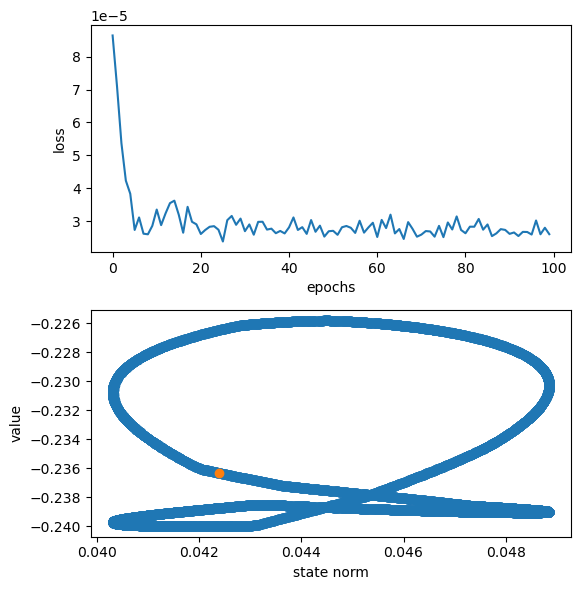

In [9]:
# --! value display --!

value_fn.eval()

lookback, reward, next_state, done = map(torch.cat, zip(*replay_buf.buffer))
obs = extract_current_state(lookback)

obs_norm = torch.squeeze(torch.linalg.norm(obs, dim=-1, ord=2))
value = torch.squeeze(value_fn(obs))

with torch.no_grad():

    plt.figure(figsize=(6,6))

    plt.subplot(2,1,1)
    plt.plot(losses)
    plt.xlabel('epochs')
    plt.ylabel('loss')

    plt.subplot(2,1,2)
    plt.scatter(obs_norm, value)
    plt.scatter(obs_norm[0], value[0])
    plt.xlabel('state norm')
    plt.ylabel('value')

    plt.tight_layout()
    plt.show()


In [10]:
# --! load a trained KIND model --!

# --! specify KIND arguments used when training the model
parser = kind.create_args_parser()
args = parser.parse_args(
    args=[
        '--file_dir', '../../data/dreamer',
        '--file_name', 'duffing',
        '--data_nsample', '8001',
        '--feature_ndim', '4',
        '--target_ndim', '2',

        '--lookback_nsample', '384',
        '--forecast_nsample', '192',

        '--batch_size', '128',
        '--nepoch', '50',
        '--patience', '10',
        '--checkpoints', '../../models/dreamer',

        '--seg_nsample_stat', '192',
        '--seg_nsample_trans', '192',
        '--fun_stat', '{"sin": 4, "cos": 4}',
        '--fun_trans', '{"sin": 6, "cos": 6}',
    ]
)

# --! instantiate a KIND model
model = kind.model(args)

# --! load trained weights into the model
model_path = args.checkpoints + '/' + 'checkpoint.pth'
model.load_state_dict(torch.load(model_path, weights_only=True))
model.eval()

# --! create a dataset
dataset = ex_duffing.dataset(
    args.file_dir, args.file_name, args.file_ext,
    args.data_nsample,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.lookback_nsample, args.forecast_nsample))

In [11]:
# --! create a trainable and bounded policy --!

u_max = 0.01

class policy_residual(torch.nn.Module):

    def __init__(self, feat, u_max):
        super().__init__()

        self.u_max = u_max
        self.net = util_nn.fcnn(feat=feat, actfun_hid='relu', actfun_o='linear')

    def forward(self, x):
        return self.u_max * torch.tanh(self.net(x))

policy_ni = 2
policy_no = 1
policy_res = policy_residual([policy_ni, 64, 64, policy_no], u_max)

In [12]:
class quadratic_fn_torch(torch.nn.Module):
    def __init__(self, Q):
        super().__init__()
        self.register_buffer("Q", torch.as_tensor(Q, dtype=torch.float32))

    def forward(self, x):
        """
        x: (B, T, d)
        returns: (B, T)
        """
        # (B, T, d) @ (d, d) -> (B, T, d)
        xQ = torch.matmul(x, self.Q)

        # elementwise multiply and sum over last dim
        return (xQ * x).sum(dim=-1, keepdim=True)

reward_fn_torch = quadratic_fn_torch(reward_fn.matrix)

In [13]:
# --! policy improvement --!

def update_lookback(lookback, obs):
    # --! make a dummy action
    u = torch.zeros(obs.shape[0], obs.shape[1], 1)
    obs = encode_obs(obs, u)
    return torch.cat([lookback[:, 1:], obs], dim=1)

def update_current_action(lookback, u):
    lookback[:, -2:, [2]] = u

# --! preparation for policy improvement --!

learning_rate = 1e-3
weight_decay = 1e-5
policy_optim = torch.optim.Adam(policy_res.parameters(), lr=learning_rate, weight_decay=weight_decay)

losses = []

# --! freeze KIND
model.eval()
for p in model.parameters():
    p.requires_grad = False

# --! freeze value
value_fn.eval()

# --! train policy
policy_res.train()

# --! Assume:
#
# --! value_fn frozen
# --! model frozen
# --! policy_res trainable
# --! policy_lqr fixed

# --! now, model rollout horizon
horizon = 10
nepoch = 100

for epoch in range(nepoch):
    policy_optim.zero_grad()

    # --! sample a random batch
    lookback, reward, next_lookback, done = replay_buf.random_batch(batch_size)

    rollout_lookback = lookback.clone()
    rollout_obs0 = extract_current_state(rollout_lookback)
    rollout_return = 0.0

    # --! do model rollouts
    for k in range(horizon):
        rollout_obs = extract_current_state(rollout_lookback)

        delta_u = policy_res(rollout_obs)
        rollout_u = policy_lqr(rollout_obs) + delta_u

        rollout_reward = reward_fn_torch(torch.cat([rollout_obs, rollout_u], dim=-1))
        rollout_return += gamma**k * rollout_reward

        update_current_action(rollout_lookback, rollout_u)

        # --! KIND predicts next state
        #
        # --! we need to manually normalize data here
        rollout_lookback = dataset.normalize(rollout_lookback, data_type='nom')
        rollout = model(dataset, rollout_lookback) # < gradients flow here

        #if k==horizon - 1:
            #with torch.no_grad():
                #plt.figure(figsize=(6,12))

                #plt.subplot(7,1,1)
                #plt.plot(rollout_lookback[0, :, :2])
                #plt.plot(rollout[0][0, :, :], linestyle='dashed')

                #plt.subplot(7,1,2)
                #plt.plot(rollout_lookback[0, :, :2])
                #plt.plot(rollout[1][0, :, :], linestyle='dashed')

                #plt.subplot(7,1,3)
                #plt.plot(rollout[2][0, :, :])

                #plt.subplot(7,1,4)
                #plt.plot(rollout_lookback[0, :, :2])
                #plt.plot(rollout[3][0, :, :], linestyle='dashed')

                #plt.subplot(7,1,5)
                #plt.plot(rollout[4][0, :, :])

                #plt.subplot(7,1,6)
                #plt.plot(rollout[9][0, :, :])

                #plt.subplot(7,1,7)
                #plt.plot(rollout_lookback[0, :, 2])
                #plt.xlabel('samples')

                #plt.tight_layout()
                #plt.show()

        # --! having a prediction, take its forecast part
        #
        # --! we need to manually denormalize data here
        rollout_lookback = dataset.denormalize(rollout_lookback, data_type='nom')
        rollout_pre = dataset.denormalize(rollout[0], data_type='nom')
        forecast = rollout_pre[:, model.args.lookback_nsample:]

        # --! take the first observation from the forecast
        rollout_next_obs = forecast[:, :1, :]

        # --! shift/update lookback using next observation
        rollout_lookback = update_lookback(rollout_lookback, rollout_next_obs)

    with torch.no_grad():
        terminal_value = value_fn(rollout_next_obs)
        current_value = value_fn(rollout_obs0)

    advantage = rollout_return + gamma**horizon * terminal_value - current_value
    policy_loss = -advantage.mean()
    losses.append(policy_loss.item())
    policy_loss.backward()
    policy_optim.step()


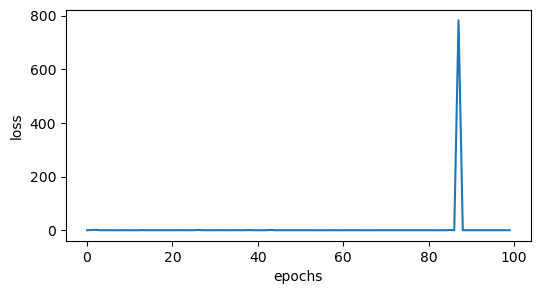

In [14]:
with torch.no_grad():

    plt.figure(figsize=(6,3))

    plt.plot(losses)
    plt.xlabel('epochs')
    plt.ylabel('loss')

    plt.show()

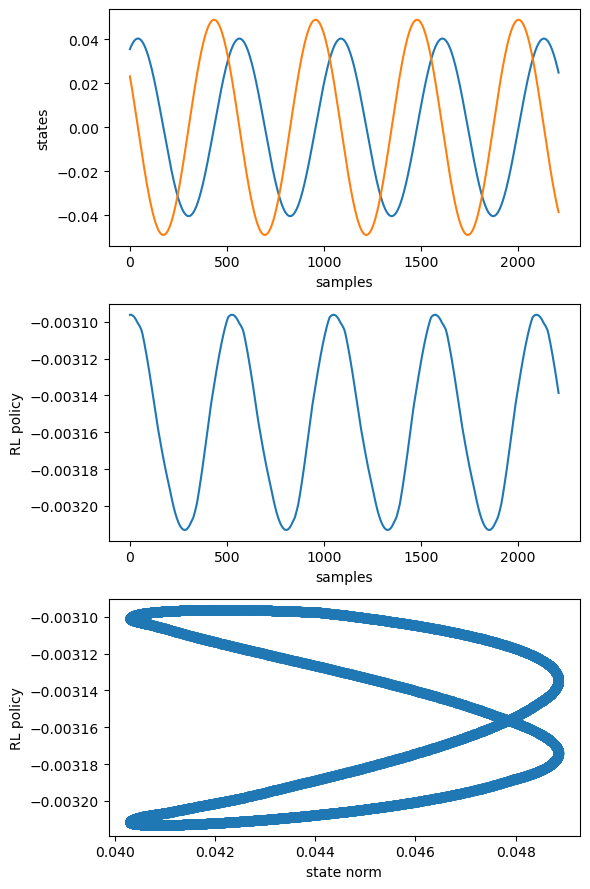

In [15]:
policy_res.eval()

lookback, reward, next_state, done = map(torch.cat, zip(*replay_buf.buffer))
obs = extract_current_state(lookback)

obs_norm = torch.squeeze(torch.linalg.norm(obs, dim=-1, ord=2))
delta_u = torch.squeeze(policy_res(obs))

obs_len = len(obs) // 4

with torch.no_grad():
    plt.figure(figsize=(6,9))

    plt.subplot(3,1,1)
    plt.plot(obs[:obs_len, 0, :2])
    plt.xlabel('samples')
    plt.ylabel('states')

    plt.subplot(3,1,2)
    plt.plot(delta_u[:obs_len])
    plt.xlabel('samples')
    plt.ylabel('RL policy')

    plt.subplot(3,1,3)
    plt.scatter(obs_norm, delta_u)
    plt.xlabel('state norm')
    plt.ylabel('RL policy')

    plt.tight_layout()
    plt.show()

torch.Size([47])
tensor(-0.0004)
tensor(4.1038e-05)


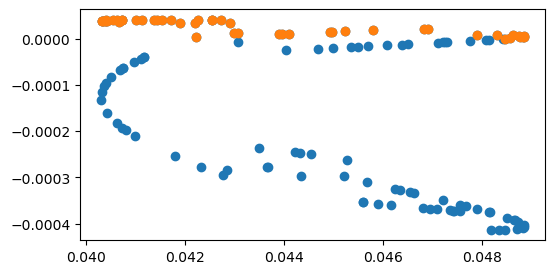

In [40]:
policy_res.eval()
value_fn.eval()

lookback, reward, next_lookback, done = replay_buf.random_batch(batch_size)
obs = extract_current_state(lookback)
obs_norm = torch.squeeze(torch.linalg.norm(obs, dim=-1, ord=2))

with torch.no_grad():

    u = policy_lqr(obs)# + policy_res(obs)
    next_obs = duffing.step_batch(obs, u)

    value = value_fn(obs)
    next_value = value_fn(next_obs)

    delta_value = torch.squeeze(next_value - value)

    mask = delta_value > 0.0
    delta_value_pos = delta_value[mask]
    print(delta_value_pos.shape)
    obs_norm_pos = obs_norm[mask]

    print(torch.min(delta_value))
    print(torch.max(delta_value))

    plt.figure(figsize=(6,3))
    plt.scatter(obs_norm, delta_value)
    plt.scatter(obs_norm_pos, delta_value_pos)
    plt.show()
    